<a href="https://colab.research.google.com/github/benhidalgov/Entregablockchain/blob/main/Entrega_1_mineria_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import OneHotEncoder
!pip install category_encoders
import category_encoders as ce

In [3]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv("epl_final.csv") # creamos un dataframe llamado df y cargamos el dataset csv

In [5]:
df.head() # visualizamos las primeras 5 filas


,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,17,8,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,17,12,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,6,16,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,6,13,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,17,12,8,6,6,4,21,20,1,3,0,0


In [ ]:
df.tail()# visualizamos las ultimas 5 filas

In [ ]:
df.shape #devuelve la cantidad de filas y columnas respectivamente

In [6]:
df.dtypes #observamos la columna y sus tipos de datos

,0
Season,object
MatchDate,object
HomeTeam,object
AwayTeam,object
FullTimeHomeGoals,int64
FullTimeAwayGoals,int64
FullTimeResult,object
HalfTimeHomeGoals,int64
HalfTimeAwayGoals,int64
HalfTimeResult,object


In [7]:
df.isnull().sum() #contamos la cantidad de nulos por columna // no notamos nulos en este dataset

,0
Season,0
MatchDate,0
HomeTeam,0
AwayTeam,0
FullTimeHomeGoals,0
FullTimeAwayGoals,0
FullTimeResult,0
HalfTimeHomeGoals,0
HalfTimeAwayGoals,0
HalfTimeResult,0


# ==========================================
# Realizaremos un mapeo de datos
# ==========================================
# * Season: Categorico Ordinal / Nominal
# * MatchDate: Categorico (Fecha)
# * HomeTeam: Categorico Nominal
# * AwayTeam: Categorico Nominal
# * FullTimeHomeGoals: Numerico Discreto
# * FullTimeAwayGoals: Numerico Discreto
# * FullTimeResult: Categorico Nominal
# * HalfTimeHomeGoals: Numerico Discreto
# * HalfTimeAwayGoals: Numerico Discreto
# * HalfTimeResult: Categorico Nominal
# * HomeShots: Numerico Discreto
# * AwayShots: Numerico Discreto
# * HomeShotsOnTarget: Numerico Discreto
# * AwayShotsOnTarget: Numerico Discreto
# * HomeCorners: Numerico Discreto
# * AwayCorners: Numerico Discreto
# * HomeFouls: Numerico Discreto
# * AwayFouls: Numerico Discreto
# * HomeYellowCards: Numerico Discreto
# * AwayYellowCards: Numerico Discreto
# * HomeRedCards: Numerico Discreto
# * AwayRedCards: Numerico Discreto


In [8]:
cant_cat_col_hometeam_df = df['HomeTeam'].value_counts() # nos mostrará la cantidad de categoricas distintas unicas de HomeTeam
print(cant_cat_col_hometeam_df)
print(f"cantidad HomeTeam: {cant_cat_col_hometeam_df.count()}") # tenemos 46 categorias distintas de equipos

HomeTeam
Everton             471
Chelsea             469
Tottenham           469
Man United          469
Arsenal             468
Liverpool           467
Man City            450
Newcastle           430
West Ham            417
Aston Villa         412
Fulham              335
Southampton         318
Sunderland          266
Leicester           245
Crystal Palace      244
West Brom           244
Blackburn           204
Bolton              204
Wolves              204
Stoke               190
Middlesbrough       187
Burnley             171
Wigan               152
Brighton            151
Bournemouth         150
Watford             133
Swansea             133
Leeds               131
Norwich             131
Birmingham          130
Charlton            128
Portsmouth          128
Hull                 95
Sheffield United     76
Brentford            75
Reading              57
QPR                  57
Derby                57
Ipswich              55
Nott'm Forest        55
Huddersfield         38
Cardiff

In [9]:
cant_cat_col_ftr_df = df['FullTimeResult'].value_counts() # nos mostrará la cantidad de categoricas distintas unicas de FullTimeResult
print(cant_cat_col_ftr_df)
print(f"cantidad FullTimeResult: {cant_cat_col_ftr_df.count()}")

FullTimeResult
H    4299
A    2768
D    2313
Name: count, dtype: int64
cantidad FullTimeResult: 3


In [10]:
df.describe()

,FullTimeHomeGoals,FullTimeAwayGoals,HalfTimeHomeGoals,HalfTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
count,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000
mean,1.535394,1.182623,0.688273,0.518763,13.617484,10.810661,5.973134,4.693710,6.040299,4.774733,11.276333,11.765672,1.468124,1.792431,0.062473,0.085288
std,1.305432,1.157414,0.835079,0.735357,5.356424,4.696501,3.267954,2.750045,3.110619,2.749541,3.750250,3.924179,1.217190,1.288481,0.253221,0.290183
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,10.000000,7.000000,4.000000,3.000000,4.000000,3.000000,9.000000,9.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,13.000000,10.000000,6.000000,4.000000,6.000000,4.000000,11.000000,12.000000,1.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,14.000000,8.000000,6.000000,8.000000,6.000000,14.000000,14.000000,2.000000,3.000000,0.000000,0.000000
max,9.000000,9.000000,5.000000,5.000000,43.000000,37.000000,24.000000,20.000000,20.000000,19.000000,33.000000,29.000000,7.000000,9.000000,3.000000,2.000000


In [11]:
# 1. OneHot Encoding para 'FullTimeResult' y 'HalfTimeResult' (baja cardinalidad)
ohe = OneHotEncoder(sparse_output=False)
ftr_htr_encoded = ohe.fit_transform(df[['FullTimeResult', 'HalfTimeResult']])

In [12]:
# Convertimos el resultado en un DataFrame con nombres de columnas claros
ftr_htr_df = pd.DataFrame(
    ftr_htr_encoded,
    columns=ohe.get_feature_names_out(['FullTimeResult', 'HalfTimeResult']),
    index=df.index
)

In [16]:
# 2. Binary Encoding para 'HomeTeam' y 'AwayTeam' usando Category Encoders
# Este encoder es ideal para columnas con alta cardinalidad como los equipos (46 categorias)
be = ce.BinaryEncoder(cols=['HomeTeam', 'AwayTeam'])
df_binary = be.fit_transform(df[['HomeTeam', 'AwayTeam']])

In [17]:
# 3. Concatenar todo y eliminar las columnas originales categoricas
# Unimos el dataframe original con las nuevas columnas
cols_to_drop = ['FullTimeResult', 'HalfTimeResult', 'HomeTeam', 'AwayTeam', 'Season', 'MatchDate']
df_final = pd.concat([df.drop(columns=cols_to_drop), ftr_htr_df, df_binary], axis=1)


In [18]:
# 4. Ver los cambios
print(df_final.head())
print(f"Total de columnas tras el mapeo: {len(df_final.columns)}")


   FullTimeHomeGoals  FullTimeAwayGoals  HalfTimeHomeGoals  HalfTimeAwayGoals  \
0                  4                  0                  2                  0   
1                  4                  2                  1                  0   
2                  1                  3                  1                  1   
3                  2                  2                  1                  2   
4                  2                  0                  2                  0   

   HomeShots  AwayShots  HomeShotsOnTarget  AwayShotsOnTarget  HomeCorners  \
0         17          8                 14                  4            6   
1         17         12                 10                  5            7   
2          6         16                  3                  9            8   
3          6         13                  4                  6            5   
4         17         12                  8                  6            6   

   AwayCorners  HomeFouls  AwayFouls  HomeYe

In [ ]:
# Visualización de Datos (Gráficas)
# 1. Distribución de Resultados a Tiempo Completo (FullTimeResult)
# H = Home Win (Victoria del local), A = Away Win (Victoria del visitante), D = Draw(Empate)

In [24]:
plt.figure(figsize=(8, 5))
# Creamos una copia de la columna temporalmente y le cambiamos los nombres (apodos)
resultados_nombres = df['FullTimeResult'].map({
    'H': 'Victoria Local',
    'D': 'Empate',
    'A': 'Victoria Visitante'
})



<Figure size 800x500 with 0 Axes>

/tmp/ipykernel_34552/3050371642.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x=resultados_nombres, palette='viridis')


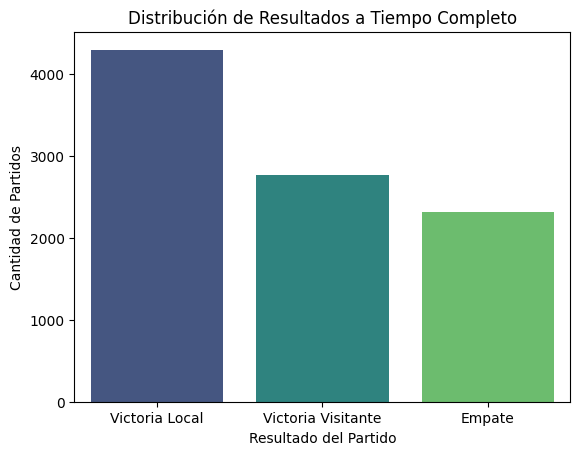

In [29]:
sb.countplot(x=resultados_nombres, palette='viridis')
plt.title('Distribución de Resultados a Tiempo Completo')
plt.xlabel('Resultado del Partido')
plt.ylabel('Cantidad de Partidos')
plt.show()

/tmp/ipykernel_34552/2807724115.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=df, x='FullTimeHomeGoals', y='HomeShotsOnTarget', palette='Reds')


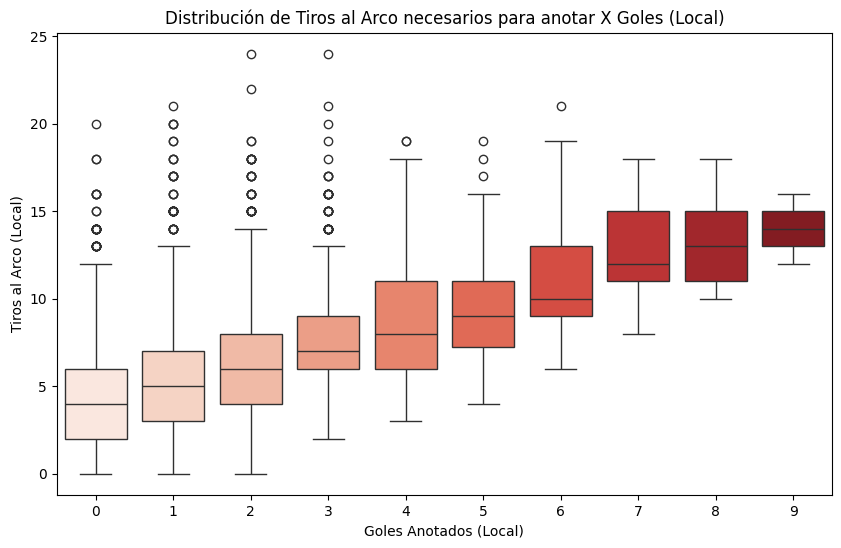

In [31]:
# 3. Relación entre Tiros al Arco del Local y Goles del Local
plt.figure(figsize=(10, 6))
sb.boxplot(data=df, x='FullTimeHomeGoals', y='HomeShotsOnTarget', palette='Reds')
plt.title('Distribución de Tiros al Arco necesarios para anotar X Goles (Local)')
plt.xlabel('Goles Anotados (Local)')
plt.ylabel('Tiros al Arco (Local)')
plt.show()


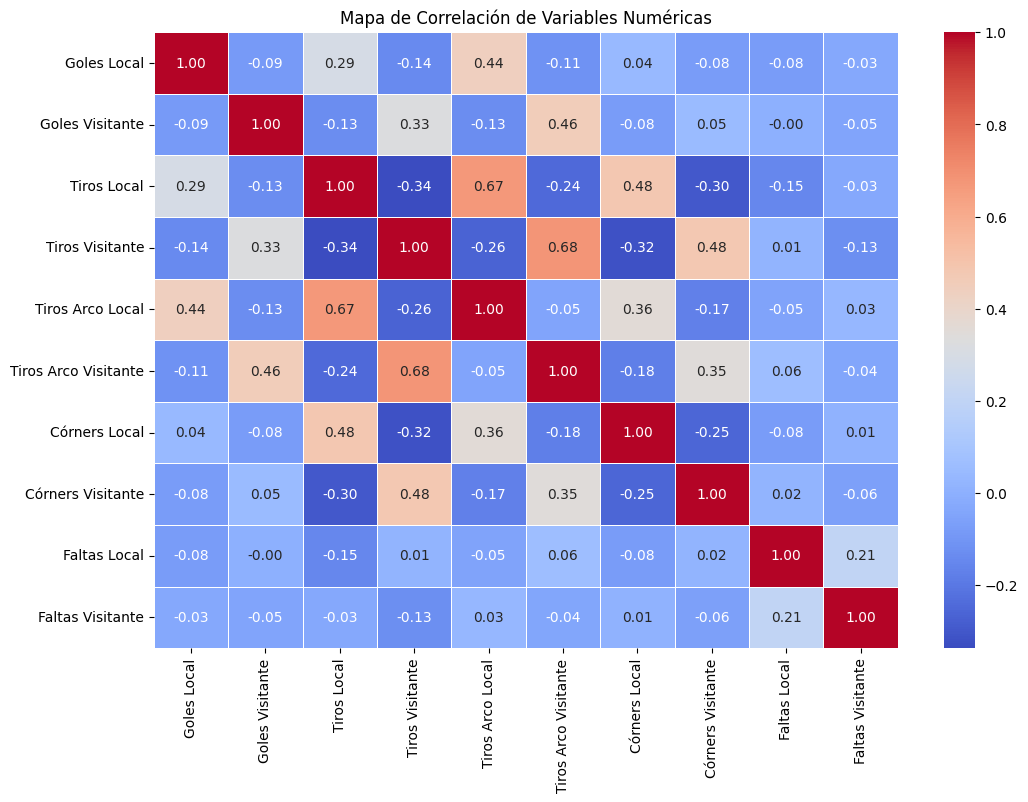

In [33]:
# Diccionario para traducir los nombres a español en la gráfica
nombres_espanol = {
    'FullTimeHomeGoals': 'Goles Local',
    'FullTimeAwayGoals': 'Goles Visitante',
    'HomeShots': 'Tiros Local',
    'AwayShots': 'Tiros Visitante',
    'HomeShotsOnTarget': 'Tiros Arco Local',
    'AwayShotsOnTarget': 'Tiros Arco Visitante',
    'HomeCorners': 'Córners Local',
    'AwayCorners': 'Córners Visitante',
    'HomeFouls': 'Faltas Local',
    'AwayFouls': 'Faltas Visitante'
}

plt.figure(figsize=(12, 8))
# Calculamos la correlación y renombramos las filas/columnas con el diccionario
correlation_matrix = df[num_cols].corr().rename(index=nombres_espanol, columns=nombres_espanol)

sb.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Correlación de Variables Numéricas')
plt.show()
